### Calculate Forecast Bias relative to ERA-5 observations for SSW vs normal seasons.

11/19/2025

F25 and S13 events, 2011-2018. No final warmings. 

In [1]:
##imports for relevant packages 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import math
import scipy.stats
import pickle

In [2]:
from MBE import openfile, calculate_errors

#write a function to create an average timeseries over SSW events.
def make_array_ssw(ssw_dates,forecast,actual):
    n_events = len(ssw_dates)
    ssw_vals = np.empty((5,n_events,36))
    for i in range(5):
         for j, (year_ind, forecast_ind) in enumerate(ssw_dates):           
            if i < 4:
                ssw_vals[i, j, :] = forecast[year_ind, forecast_ind, i, :]
            else:
                ssw_vals[i, j, :] = actual[year_ind, forecast_ind, :]
    #take average of events 
    ssw_vals = np.nanmean(ssw_vals, axis = 1)
    return ssw_vals

In [3]:
##ssw date indexes based on F25/S13. 
#1/7/13, 1/7/2014, 2/4/2014, 12/31/2014, 01/28/2017, 02/10/2018
ssw_dates = [(1,2),(2,2),(2,5),(3,2),(5,5),(6,6)]
#ssw_dates = [(1,2),(2,5),(5,5),(6,6)]

In [4]:
#I would like to say thank you to DS&A for this one.
years = range(0, 7)
events = range(0, 8)

#convert list to a set for fast lookup
present = set(ssw_dates)

#collect normal event dates not in ssw events
normal_events = [(y, e) for y in years for e in events if (y, e) not in present]
len(normal_events)

50

In [5]:
#open ERA-5 and UFS data ... make ssw file
#zonal mean wind
w_actual, w_forecast = openfile("ERA5_wind10","UFS_wind10")
ssw_wind = make_array_ssw(ssw_dates,w_forecast,w_actual)
climo_wind = make_array_ssw(normal_events,w_forecast,w_actual)

#size 
sz_actual, sz_forecast = openfile("ERA5_size10","UFS_size10")
ssw_size = make_array_ssw(ssw_dates,sz_forecast,sz_actual)
climo_size = make_array_ssw(normal_events,sz_forecast,sz_actual)

#cenlat 
cenlat_actual, cenlat_forecast = openfile("ERA5_cenlat10","UFS_cenlat10")
ssw_cenlat = make_array_ssw(ssw_dates,cenlat_forecast,cenlat_actual)
climo_cenlat = make_array_ssw(normal_events,cenlat_forecast,cenlat_actual)

#cenlon
cenlon_actual, cenlon_forecast = openfile("ERA5_cenlon10","UFS_cenlon10")
ssw_cenlon = make_array_ssw(ssw_dates,cenlon_forecast,cenlon_actual)
climo_cenlon = make_array_ssw(normal_events,cenlon_forecast,cenlon_actual)

#ratio 
ratio_actual, ratio_forecast = openfile("ERA5_ratio10","UFS_ratio10")
ssw_ratio = make_array_ssw(ssw_dates,ratio_forecast,ratio_actual)
climo_ratio = make_array_ssw(normal_events,ratio_forecast,ratio_actual)

#ephi
ephi_actual, ephi_forecast = openfile("ERA5_ephi10","UFS_ephi10")
ssw_ephi = make_array_ssw(ssw_dates,ephi_forecast,ephi_actual)
climo_ephi = make_array_ssw(normal_events,ephi_forecast,ephi_actual)

#number
number_actual, number_forecast = openfile("ERA5_number10","UFS_number10")
ssw_number = make_array_ssw(ssw_dates,number_forecast,number_actual)
climo_number = make_array_ssw(normal_events,number_forecast,number_actual)

In [6]:
%matplotlib inline
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
myLocator = mticker.MultipleLocator(5)

#DESIGNATE LIST OF PROTOTYPES.
prototype = ["Prototype5","Prototype6","Prototype7","Prototype8"]
#Designate range of forecast days observed in UFS
forecast_days = [i for i in range(0,36,1)]

colors = ["midnightblue","royalblue","mediumvioletred","magenta"]

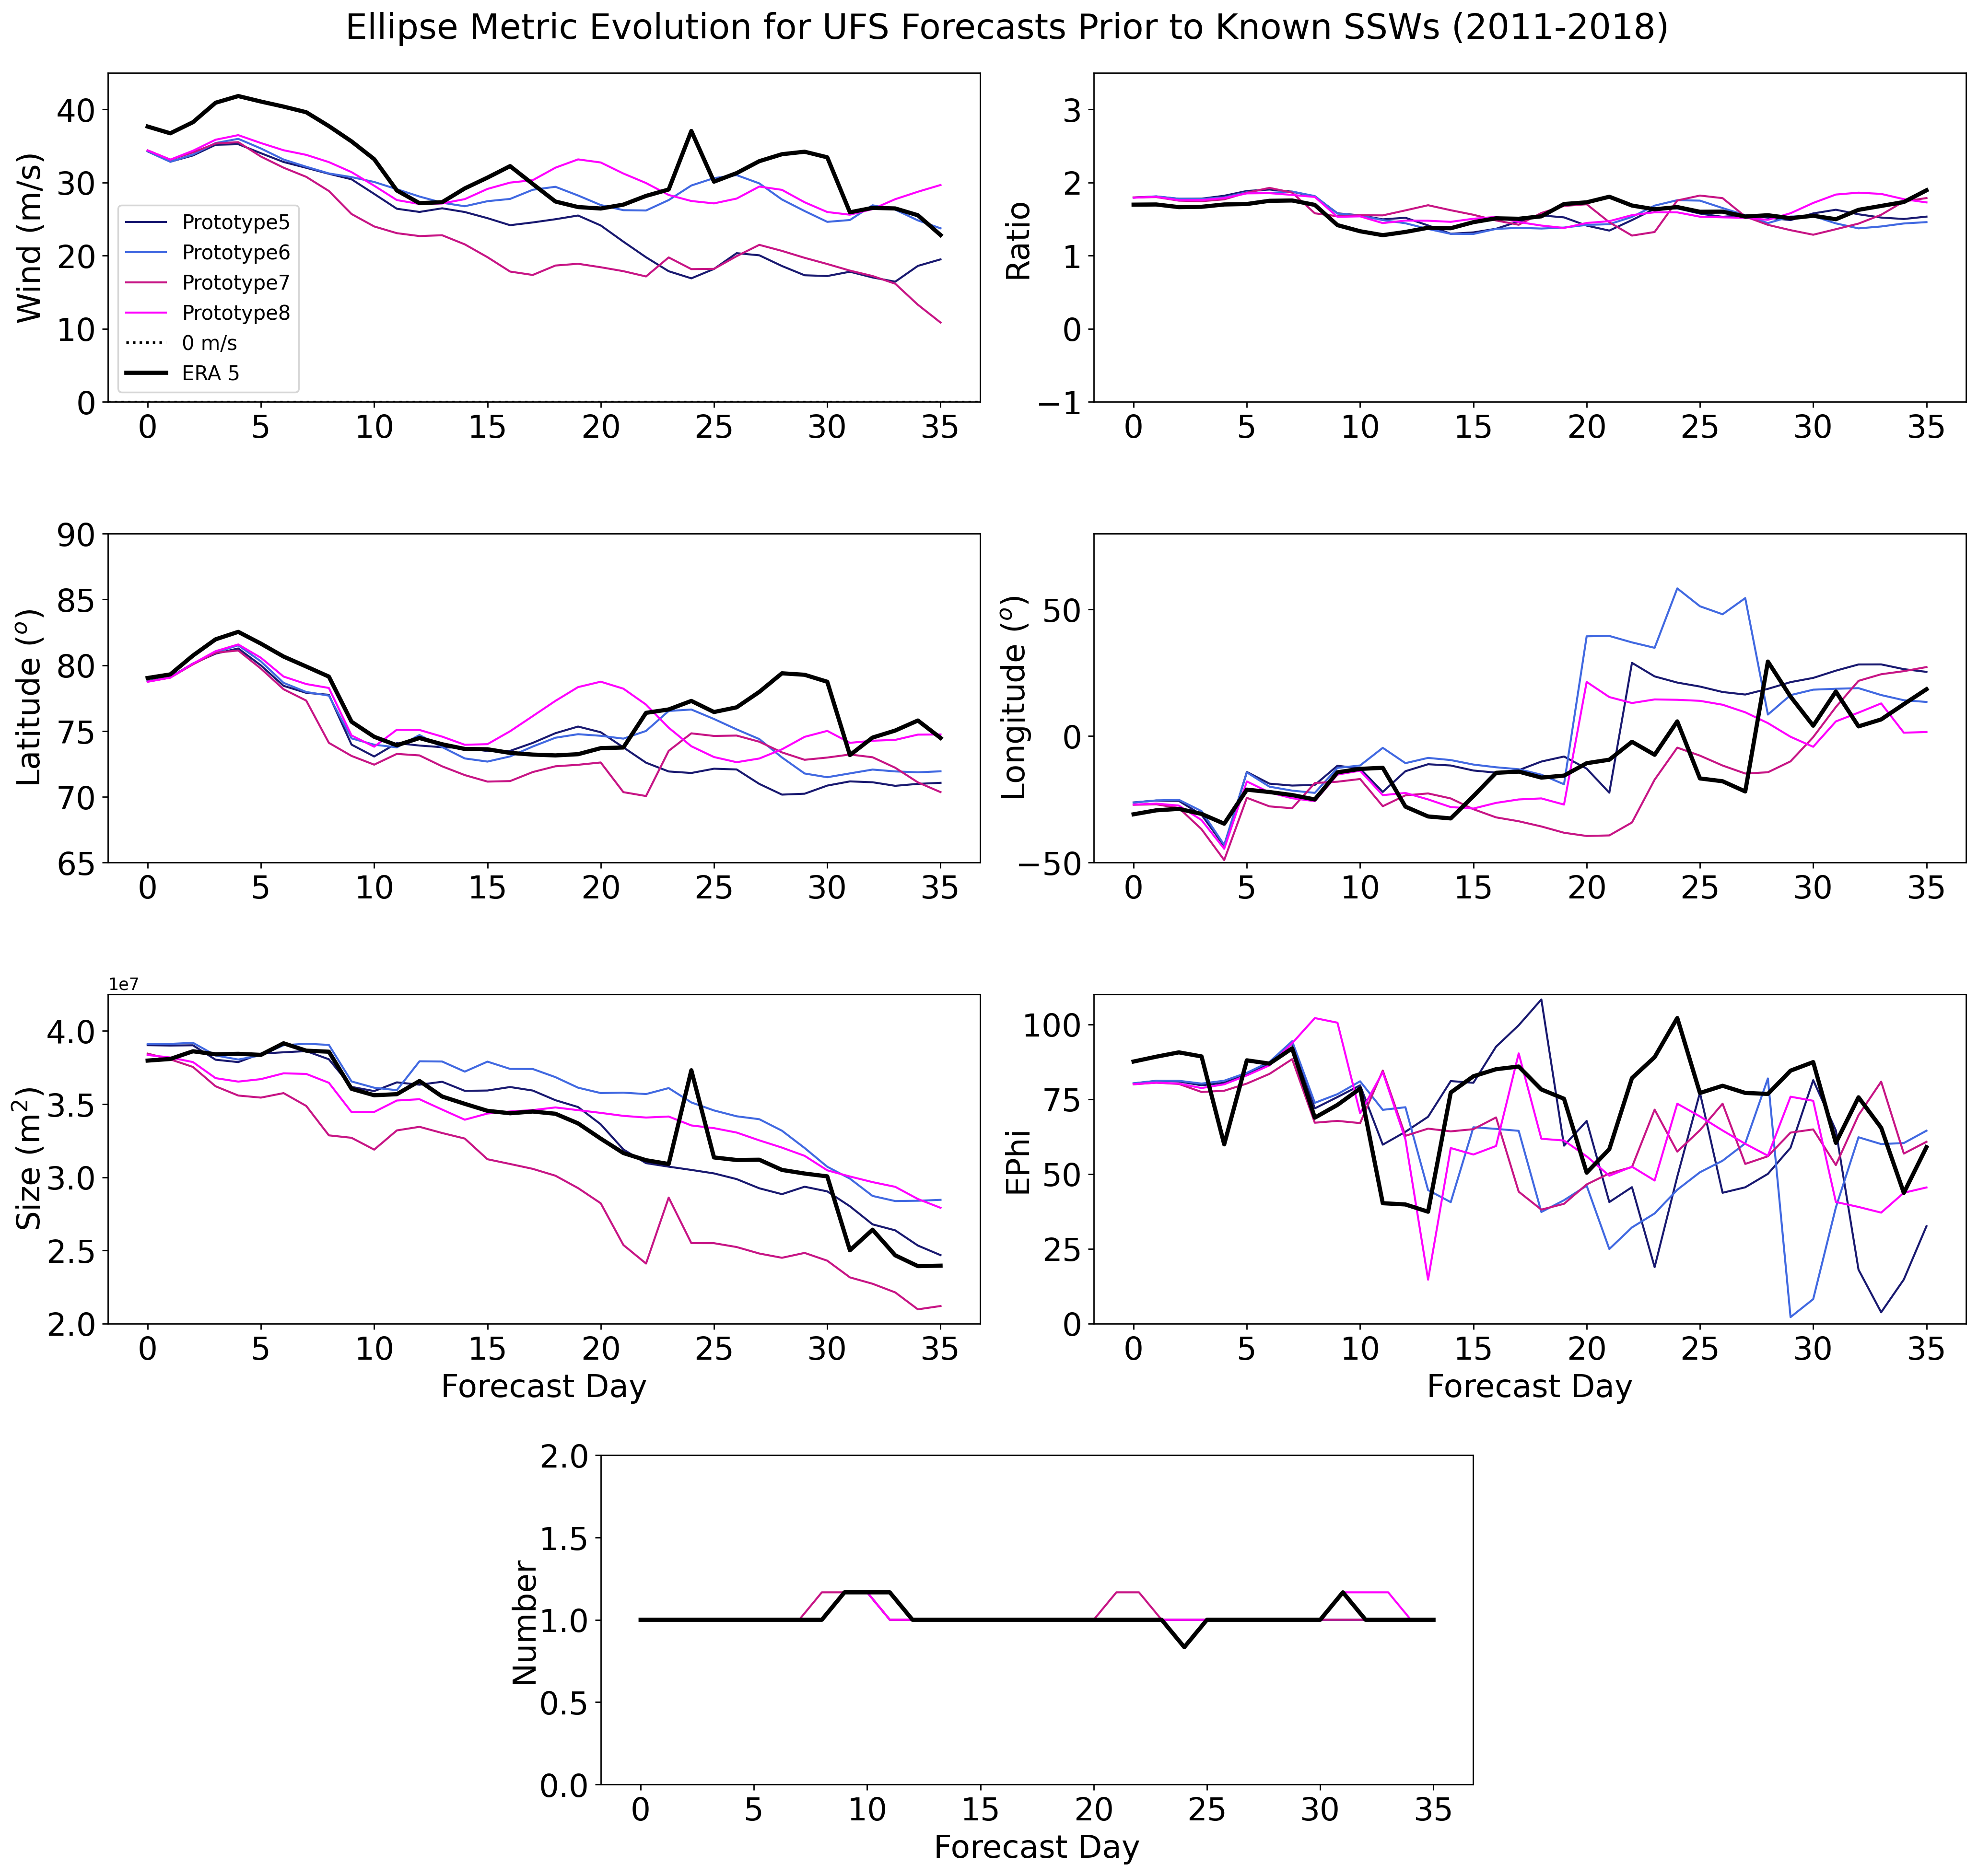

In [14]:
fig = plt.figure(figsize=(20,17), dpi=250)

#4x4 grid for better control of spacing
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.4, wspace=0.3)

#6 subplots in a 3x2 layout, each using two columns
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[2, 0:2])
ax6 = fig.add_subplot(gs[2, 2:4])

#Centered seventh subplot at the bottom ... spanning columns 1 to 3
ax7 = fig.add_subplot(gs[3, 1:3])

fs = 19

for m in range(0, 5):
    if m == 4: 
        label = 'ERA 5'
        color = 'k'
        linewidth = 2.5
        ax1.axhline(y=0, color='k', linestyle=':', label="0 m/s")
    else: 
        label = str(prototype[m])
        color = colors[m]
        linewidth = 1.2

    ax1.plot(forecast_days, ssw_wind[m, :], color=color, label=label, linewidth=linewidth)
    ax2.plot(forecast_days, ssw_ratio[m,:], color=color, label=label, linewidth=linewidth)
    ax3.plot(forecast_days, ssw_cenlat[m, :], color=color, label=label, linewidth=linewidth)
    ax4.plot(forecast_days, ssw_cenlon[m, :], color=color, label=label, linewidth=linewidth)
    ax5.plot(forecast_days, ssw_size[m, :], color=color, label=label, linewidth=linewidth)
    ax6.plot(forecast_days, ssw_ephi[m, :], color=color, label=label, linewidth=linewidth)

    #example data for subplot 7 — replace with actual
    ax7.plot(forecast_days, ssw_number[m, :], color=color, label=label, linewidth=linewidth)

#axis labels & formatting
ax1.set_ylabel('Wind (m/s)', fontsize=fs)
ax1.set_ylim(0,45)
ax2.set_ylabel('Ratio', fontsize=fs)
ax2.set_ylim(-1, 3.5)
ax3.set_ylabel('Latitude ($^o$)', fontsize=fs)
ax3.set_ylim(65,90)
ax4.set_ylabel('Longitude ($^o$)', fontsize=fs)
ax4.set_ylim(-50,80)
ax5.set_ylabel('Size (m$^2$)', fontsize=fs)
ax5.set_ylim(20000000,42500000)
ax5.set_xlabel('Forecast Day', fontsize=fs)
ax6.set_ylabel('EPhi', fontsize=fs)
ax6.set_ylim(0,110)
ax6.set_xlabel('Forecast Day', fontsize=fs)
ax7.set_ylabel('Number', fontsize=fs)
ax7.set_ylim(0,2)
ax7.set_xlabel('Forecast Day', fontsize=fs)

#common formatting for ticks
for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
    ax.tick_params(axis='both', which='major', labelsize=fs)
    ax.yaxis.set_label_coords(-0.07, 0.5) #move the y labels to be equal

ax1.legend(loc='lower left', fontsize='large')

plt.suptitle("Ellipse Metric Evolution for UFS Forecasts Prior to Known SSWs (2011-2018)", fontsize=21)
plt.subplots_adjust(top=0.95)
#plt.tight_layout()
#plt.show()
plt.savefig("SSW_test.png")

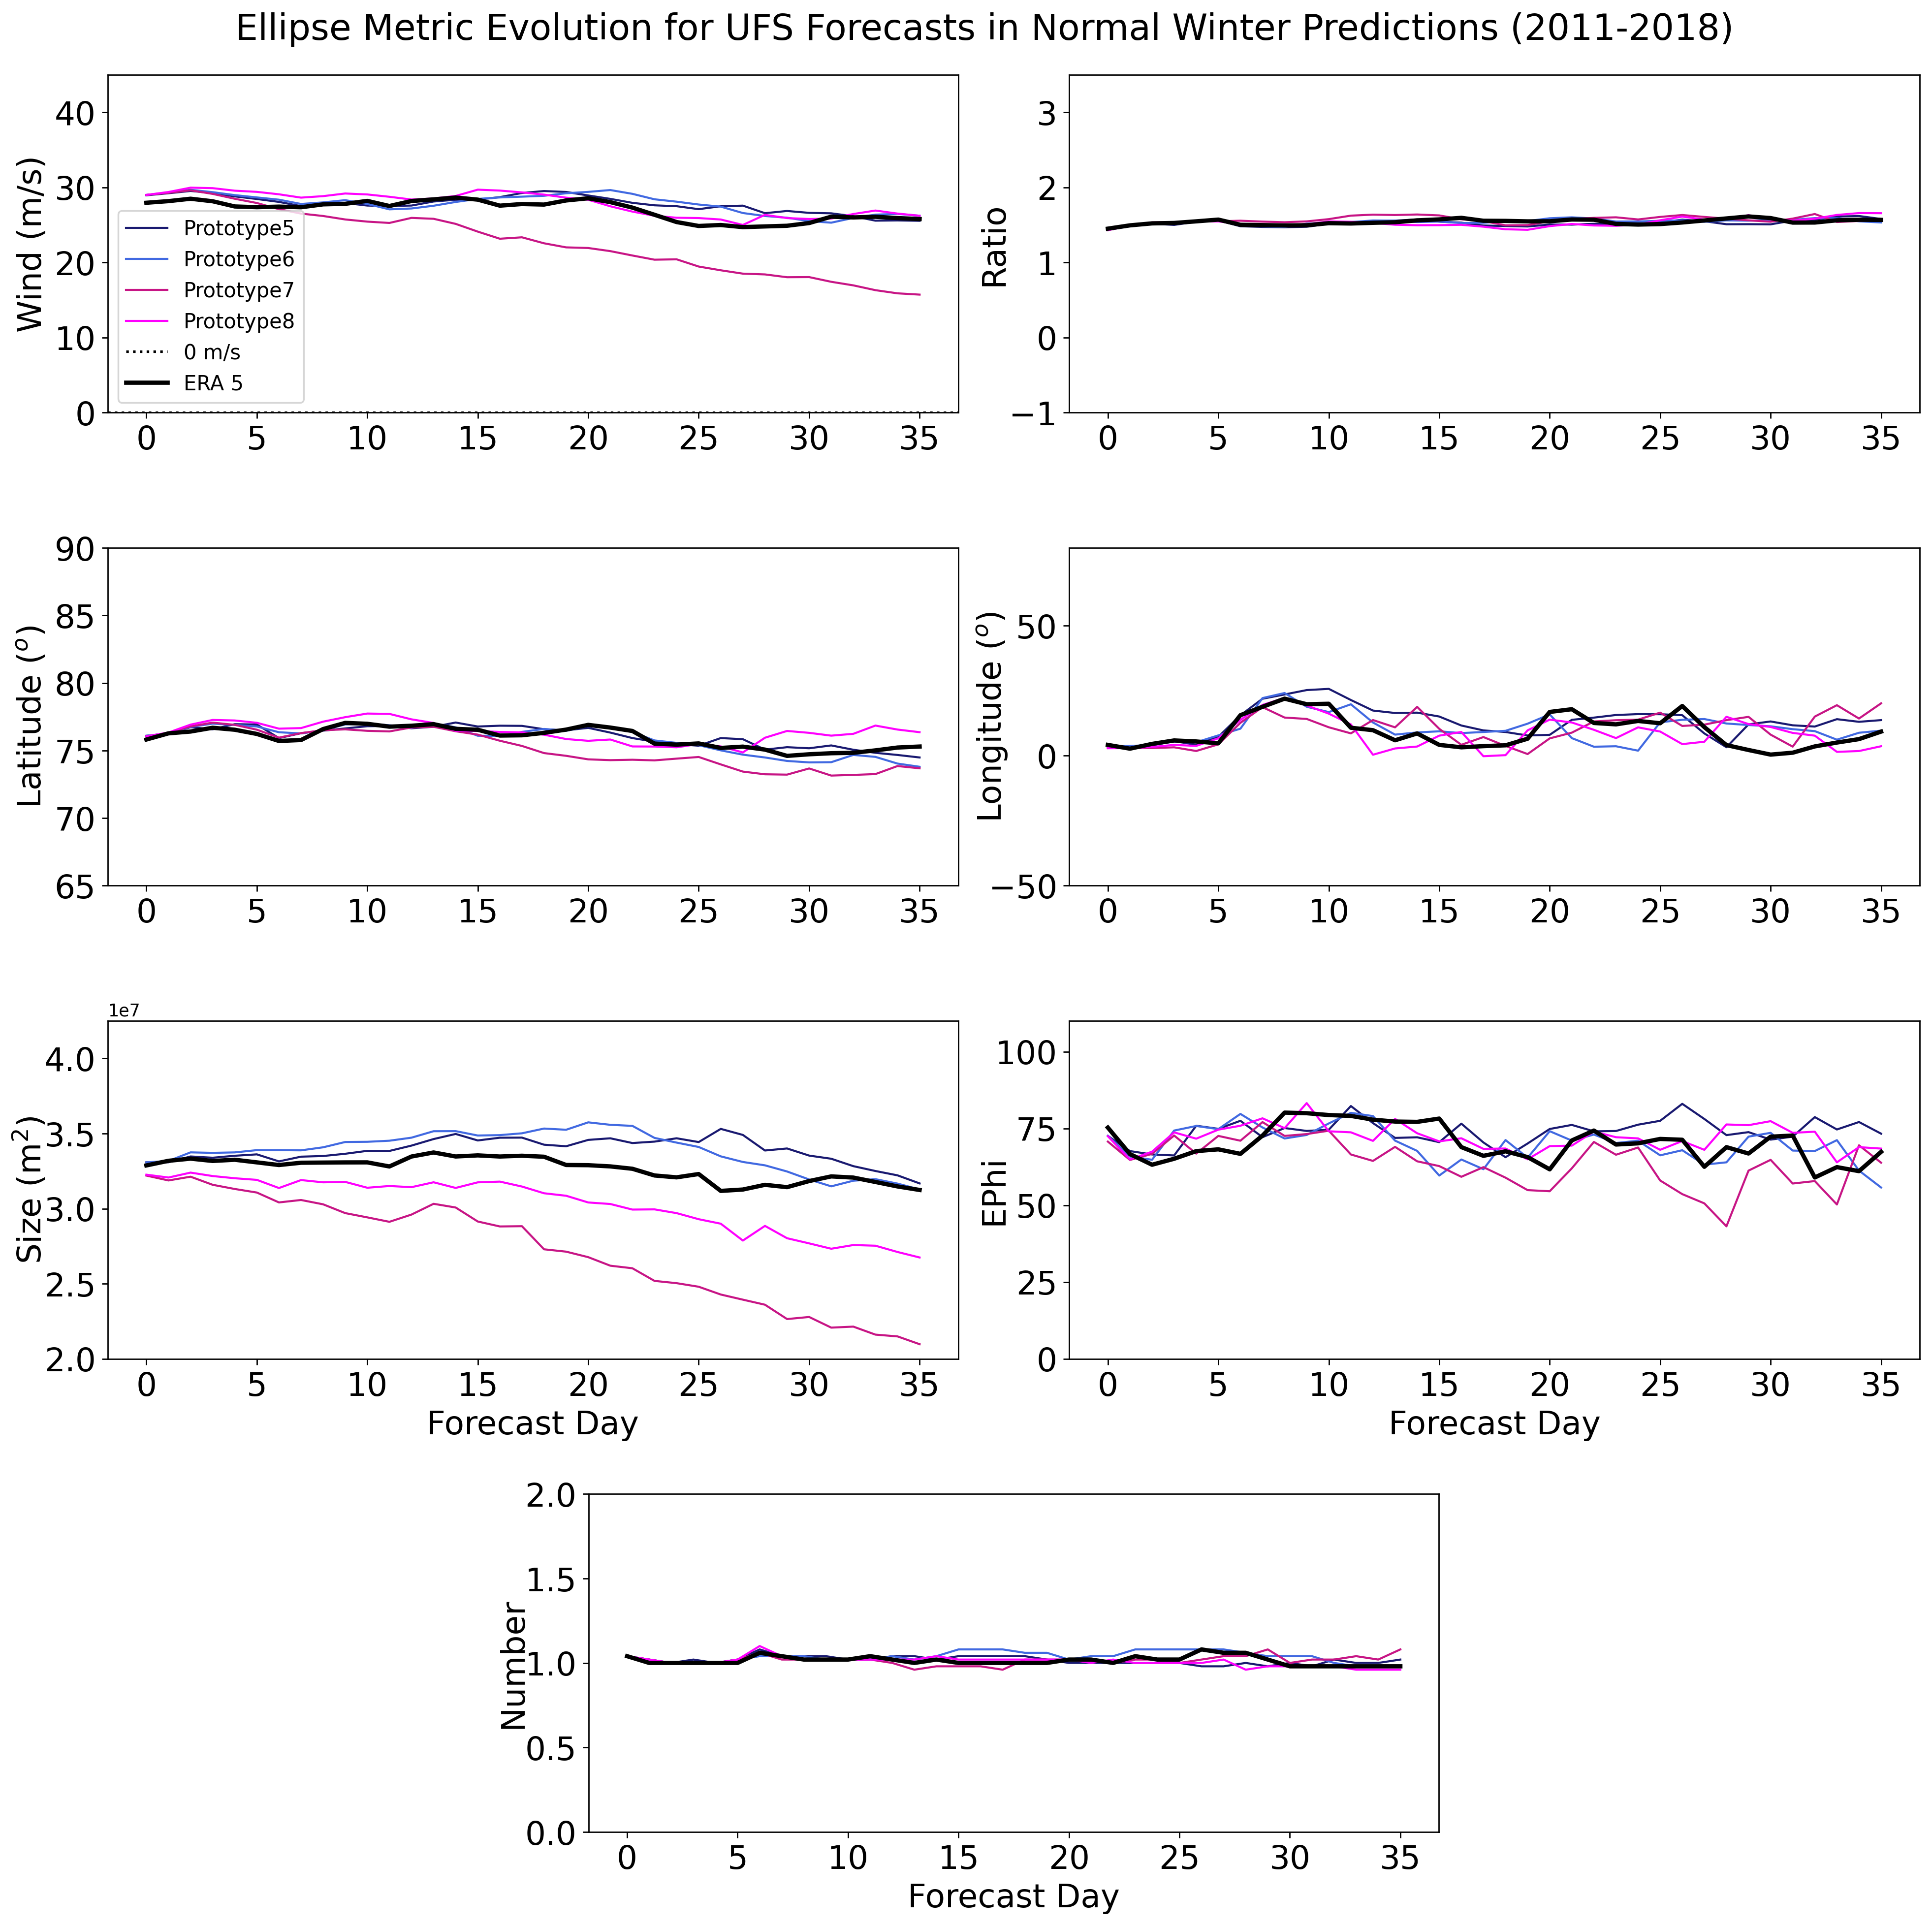

In [15]:
fig = plt.figure(figsize=(19,17), dpi=250)

#4x4 grid for better control of spacing
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.4, wspace=0.3)

#6 subplots in a 3x2 layout, each using two columns
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[2, 0:2])
ax6 = fig.add_subplot(gs[2, 2:4])

#Centered seventh subplot at the bottom ... spanning columns 1 to 3
ax7 = fig.add_subplot(gs[3, 1:3])

fs = 19

for m in range(0, 5):
    if m == 4: 
        label = 'ERA 5'
        color = 'k'
        linewidth = 2.5
        ax1.axhline(y=0, color='k', linestyle=':', label="0 m/s")
    else: 
        label = str(prototype[m])
        color = colors[m]
        linewidth = 1.2

    ax1.plot(forecast_days, climo_wind[m, :], color=color, label=label, linewidth=linewidth)
    ax2.plot(forecast_days, climo_ratio[m, :], color=color, label=label, linewidth=linewidth)
    ax3.plot(forecast_days, climo_cenlat[m, :], color=color, label=label, linewidth=linewidth)
    ax4.plot(forecast_days, climo_cenlon[m, :], color=color, label=label, linewidth=linewidth)
    ax5.plot(forecast_days, climo_size[m, :], color=color, label=label, linewidth=linewidth)
    ax6.plot(forecast_days, climo_ephi[m, :], color=color, label=label, linewidth=linewidth)

    #example data for subplot 7 — replace with actual
    ax7.plot(forecast_days, climo_number[m, :], color=color, label=label, linewidth=linewidth)

#axis labels & formatting
ax1.set_ylabel('Wind (m/s)', fontsize=fs)
ax1.set_ylim(0,45)
ax2.set_ylabel('Ratio', fontsize=fs)
ax2.set_ylim(-1, 3.5)
ax3.set_ylabel('Latitude ($^o$)', fontsize=fs)
ax3.set_ylim(65,90)
ax4.set_ylabel('Longitude ($^o$)', fontsize=fs)
ax4.set_ylim(-50,80)
ax5.set_ylabel('Size (m$^2$)', fontsize=fs)
ax5.set_ylim(20000000,42500000)
ax5.set_xlabel('Forecast Day', fontsize=fs)
ax6.set_ylabel('EPhi', fontsize=fs)
ax6.set_ylim(0,110)
ax6.set_xlabel('Forecast Day', fontsize=fs)
ax7.set_ylabel('Number', fontsize=fs)
ax7.set_ylim(0,2)
ax7.set_xlabel('Forecast Day', fontsize=fs)

#common formatting for ticks
for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
    ax.tick_params(axis='both', which='major', labelsize=fs)
    ax.yaxis.set_label_coords(-0.07, 0.5) #move the y labels to be equal


ax1.legend(loc='lower left', fontsize='large')

plt.suptitle("Ellipse Metric Evolution for UFS Forecasts in Normal Winter Predictions (2011-2018)", fontsize=21)
plt.subplots_adjust(top=0.95)
#plt.tight_layout()
#plt.show()
plt.savefig("Normal_test.png")

In [9]:
#first,verify 2m UFS temp for the last two weeks just to see how bad it actually is 
#if so, test the RF model with first two weeks of vortex metrics to see whether there is any improvement in forecasting these temperatures.

##RF input would be (#samples ... 7*5*14 days ... 8 features)
#this would be relevant to looking at the operational implementation of the RF model. 

#or is there a way to use the RF to post-process the UFS


##take graphcast 2019 event data and plot gif 